<div class="alert alert-block alert-success">
<b>Comentario general del revisor</b> <a class="tocSkip"></a><br />
Status del proyecto: <b>Aprobado</b>

</div>


¡Hola!<br />
Soy **Francisco Cortés**, estoy contento de revisar tu proyecto y ser parte de tu proceso de aprendizaje.
A lo largo del texto, haré algunas observaciones sobre mejoras en el código y también haré comentarios sobre tus percepciones sobre el tema. Si existe algún error en el código, no te preocupes, estoy aquí para ayudarte a mejorarlo, en la primera iteración te lo señalaré para que tengas la oportunidad de corregirlo, pero si aún no encuentras una solución para esta tarea, te daré una pista más precisa en la próxima iteración y también algunos ejemplos prácticos. Estaré abierto a retroalimentación y discusiones sobre el tema.<br />
Encontrarás mis comentarios a continuación - **por favor no los muevas, modifiques o borres**.
Revisaré cuidadosamente tu código para comprobar que se han cumplido con los requisitos y te proporcionaré mis comentarios en cajas verdes, amarillas o rojas como esta:

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si la ejecución fue perfecta succesfully.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si existe alguna recomendación para que tu código mejore.
</div>

<div class="alert alert-block alert-danger">

<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si existen correcciones necesarias para cumplir con los requisitos. El trabajo no puede ser aceptado si hay alguna caja roja.
</div>

Puedes responderme de la siguiente manera:

<div class="alert alert-block alert-info">
<b>Respuesta del estudiante.</b> <a class="tocSkip"></a>
</div>

# Proyecto venta de juegos

# 1. Lectura de datos


In [1]:
# importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# lectura de datos
games = pd.read_csv('/datasets/games.csv')
games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [3]:
games.sample(10)

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
15865,Bomberman 2,DS,2008.0,Puzzle,0.00,0.01,0.00,0.00,NaN,NaN,NaN
11920,Tom Clancy's Ghost Recon 2,GC,2005.0,Shooter,0.06,0.01,0.00,0.00,54.0,1.4,T
12920,Adventure Time: Finn & Jake Investigations,XOne,2015.0,Action,0.03,0.02,0.00,0.00,NaN,NaN,NaN
9780,Sword Art Online: Hollow Fragment,PS4,2015.0,Role-Playing,0.00,0.10,0.00,0.02,NaN,NaN,NaN
11887,Romance of the Three Kingdoms XI,PS2,2007.0,Strategy,0.00,0.00,0.07,0.00,69.0,8.4,E10+
7267,Saltwater Sportfishing,PS,2001.0,Sports,0.12,0.08,0.00,0.01,NaN,NaN,NaN
12983,Bass Rise,PS,1999.0,Sports,0.03,0.02,0.00,0.00,NaN,NaN,NaN
10524,FIFA Street,XB,2005.0,Sports,0.08,0.02,0.00,0.00,60.0,8,E
13673,Split/Second,PC,2010.0,Racing,0.00,0.04,0.00,0.01,79.0,8.2,E10+
8820,3rd Super Robot Wars Z: Tengoku-Hen,PS3,2015.0,Action,0.00,0.00,0.15,0.00,NaN,NaN,NaN


# 2.Limpieza de Datos

In [4]:
# Poner el nombre de las columnas en minusculas
games = games.rename(columns=str.lower)

In [5]:
# Análisis completo de datos faltantes
print("=== ANÁLISIS DE DATOS FALTANTES ===\n")

# Contar valores faltantes por columna
missing_counts = games.isnull().sum()
missing_percentage = (missing_counts / len(games)) * 100

print(missing_counts)
print(missing_percentage)

=== ANÁLISIS DE DATOS FALTANTES ===

name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         6701
rating             6766
dtype: int64
name                0.011965
platform            0.000000
year_of_release     1.609333
genre               0.011965
na_sales            0.000000
eu_sales            0.000000
jp_sales            0.000000
other_sales         0.000000
critic_score       51.319174
user_score         40.089740
rating             40.478612
dtype: float64


In [6]:
# Convertir year_of_release usando Int64 que permite NaN
games['year_of_release'] = games['year_of_release'].astype('Int64')
print("Conversión exitosa. Tipo de datos:", games['year_of_release'].dtype)
print("Valores faltantes mantenidos:", games['year_of_release'].isnull().sum())

Conversión exitosa. Tipo de datos: Int64
Valores faltantes mantenidos: 269


In [7]:
# Investigar y limpiar user_score
print("Valores únicos en user_score:")
print(games['user_score'].value_counts(dropna=False).head(10))

# Convertir 'tbd' a NaN y luego a numérico
games['user_score'] = games['user_score'].replace('tbd', np.nan)
games['user_score'] = pd.to_numeric(games['user_score'], errors='coerce')

print(f"\nDespués de la limpieza:")
print(f"Tipo de datos: {games['user_score'].dtype}")
print(f"Valores faltantes: {games['user_score'].isnull().sum()}")

Valores únicos en user_score:
NaN    6701
tbd    2424
7.8     324
8       290
8.2     282
8.3     254
8.5     253
7.5     251
7.9     249
8.1     244
Name: user_score, dtype: int64

Después de la limpieza:
Tipo de datos: float64
Valores faltantes: 9125


In [8]:
# Manejar los pocos valores faltantes en name y genre
print("Filas con name faltante:")
print(games[games['name'].isnull()])

print("\nFilas con genre faltante:")
print(games[games['genre'].isnull()])

# Opción: eliminar estas filas (son muy pocas)
games = games.dropna(subset=['name', 'genre'])
print(f"\nFilas restantes después de limpiar: {len(games)}")

Filas con name faltante:
      name platform  year_of_release genre  na_sales  eu_sales  jp_sales  \
659    NaN      GEN             1993   NaN      1.78      0.53      0.00   
14244  NaN      GEN             1993   NaN      0.00      0.00      0.03   

       other_sales  critic_score  user_score rating  
659           0.08           NaN         NaN    NaN  
14244         0.00           NaN         NaN    NaN  

Filas con genre faltante:
      name platform  year_of_release genre  na_sales  eu_sales  jp_sales  \
659    NaN      GEN             1993   NaN      1.78      0.53      0.00   
14244  NaN      GEN             1993   NaN      0.00      0.00      0.03   

       other_sales  critic_score  user_score rating  
659           0.08           NaN         NaN    NaN  
14244         0.00           NaN         NaN    NaN  

Filas restantes después de limpiar: 16713


In [9]:
games.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16713 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16713 non-null  object 
 2   year_of_release  16444 non-null  Int64  
 3   genre            16713 non-null  object 
 4   na_sales         16713 non-null  float64
 5   eu_sales         16713 non-null  float64
 6   jp_sales         16713 non-null  float64
 7   other_sales      16713 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       7590 non-null   float64
 10  rating           9949 non-null   object 
dtypes: Int64(1), float64(6), object(4)
memory usage: 1.5+ MB


## Ventas totales

In [10]:
# Calcular las ventas totales sumando todas las regiones
games['total_sales'] = games['na_sales'] + games['eu_sales'] + games['jp_sales'] + games['other_sales']

# Verificar que la nueva columna se creó correctamente
print("Nueva columna 'total_sales' creada exitosamente!")
print(f"Tipo de datos: {games['total_sales'].dtype}")
print(f"Valores faltantes: {games['total_sales'].isnull().sum()}")

# Mostrar estadísticas básicas de las ventas totales
print("\nEstadísticas de ventas totales:")
print(games['total_sales'].describe())

Nueva columna 'total_sales' creada exitosamente!
Tipo de datos: float64
Valores faltantes: 0

Estadísticas de ventas totales:
count    16713.000000
mean         0.533315
std          1.548282
min          0.000000
25%          0.060000
50%          0.170000
75%          0.470000
max         82.540000
Name: total_sales, dtype: float64


In [11]:
# Verificar que la nueva columna se creó correctamente
print("Nueva columna 'total_sales' creada exitosamente!")
print(f"Tipo de datos: {games['total_sales'].dtype}")
print(f"Valores faltantes: {games['total_sales'].isnull().sum()}")

# Mostrar estadísticas básicas de las ventas totales
print("\nEstadísticas de ventas totales:")
print(games['total_sales'].describe())

Nueva columna 'total_sales' creada exitosamente!
Tipo de datos: float64
Valores faltantes: 0

Estadísticas de ventas totales:
count    16713.000000
mean         0.533315
std          1.548282
min          0.000000
25%          0.060000
50%          0.170000
75%          0.470000
max         82.540000
Name: total_sales, dtype: float64


Para tratar los datos faltantes en nuestro conjunto de datos tuve que convertir tbd a valor faltante debido a estos valores no nos dan informacion especifica y en terminos generales preferi dejar los valores faltantes debido a que si eliminaba esos valores podria perder mucha informacion.

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Bien hecho!<br/>

Hiciste un buen trabajo al cambiar los nombres de las columnas, sus tipos de datos y reemplazar los valores ausentes
</div>


# 3. Analisis de Datos

In [12]:
# Análisis de juegos lanzados por año
print("=== ANÁLISIS DE LANZAMIENTOS POR AÑO ===\n")

# Contar juegos por año (excluyendo NaN)
games_per_year = games['year_of_release'].value_counts().sort_index()

print("Juegos lanzados por año:")
print(games_per_year)

# Mostrar estadísticas básicas
print(f"\nPeríodo de datos: {games_per_year.index.min()} - {games_per_year.index.max()}")
print(f"Total de años con datos: {len(games_per_year)}")
print(f"Promedio de juegos por año: {games_per_year.mean():.1f}")

=== ANÁLISIS DE LANZAMIENTOS POR AÑO ===

Juegos lanzados por año:
1980       9
1981      46
1982      36
1983      17
1984      14
1985      14
1986      21
1987      16
1988      15
1989      17
1990      16
1991      41
1992      43
1993      60
1994     121
1995     219
1996     263
1997     289
1998     379
1999     338
2000     350
2001     482
2002     829
2003     775
2004     762
2005     939
2006    1006
2007    1197
2008    1427
2009    1426
2010    1255
2011    1136
2012     653
2013     544
2014     581
2015     606
2016     502
Name: year_of_release, dtype: Int64

Período de datos: 1980 - 2016
Total de años con datos: 37
Promedio de juegos por año: 444.4


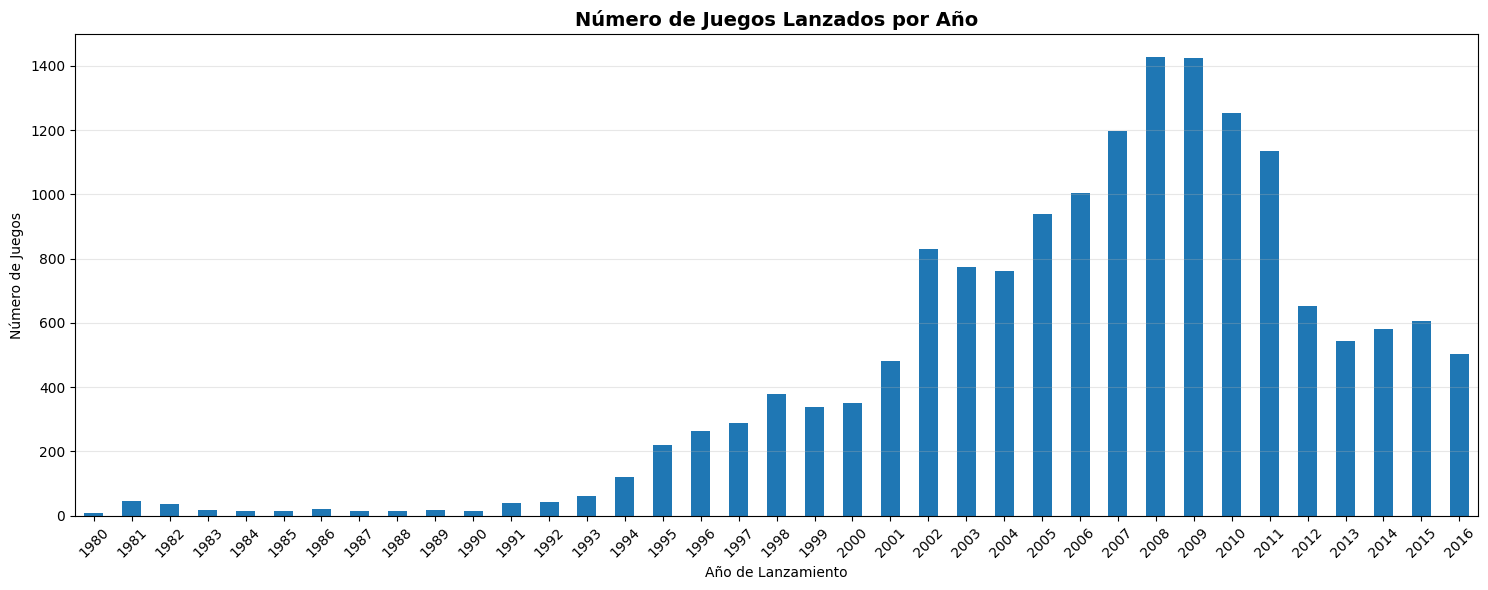

Análisis de años recientes (2010-2016):
2010    1255
2011    1136
2012     653
2013     544
2014     581
2015     606
2016     502
Name: year_of_release, dtype: Int64


In [13]:
# Visualización de lanzamientos por año
plt.figure(figsize=(15, 6))
games_per_year.plot(kind='bar')
plt.title('Número de Juegos Lanzados por Año', fontsize=14, fontweight='bold')
plt.xlabel('Año de Lanzamiento')
plt.ylabel('Número de Juegos')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Análisis de años recientes (más relevantes para predecir 2017)
print("Análisis de años recientes (2010-2016):")
recent_years = games_per_year[games_per_year.index >= 2010]
print(recent_years)

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Correcto!<br/>

Buena manera de presentar los datos, podemos ver claramente la tendencia de los videojuegos con un incremento constante en años anteriores que ha empezado a ir en declive en los últimos años
</div>


#### ¿Son significativos los datos de cada período?

#### 3.2 Observa cómo varían las ventas de una plataforma a otra. Elige las plataformas con las mayores ventas totales y construye una distribución basada en los datos de cada año. Busca las plataformas que solían ser populares pero que ahora no tienen ventas. ¿Cuánto tardan generalmente las nuevas plataformas en aparecer y las antiguas en desaparecer?

 #### ¿Cuánto tardan generalmente las nuevas plataformas en aparecer y las antiguas en desaparecer?

Top 10 plataformas por ventas totales:
platform
PS2     1255.77
X360     971.42
PS3      939.65
Wii      907.51
DS       806.12
PS       730.86
GBA      317.85
PS4      314.14
PSP      294.05
PC       259.52
Name: total_sales, dtype: float64


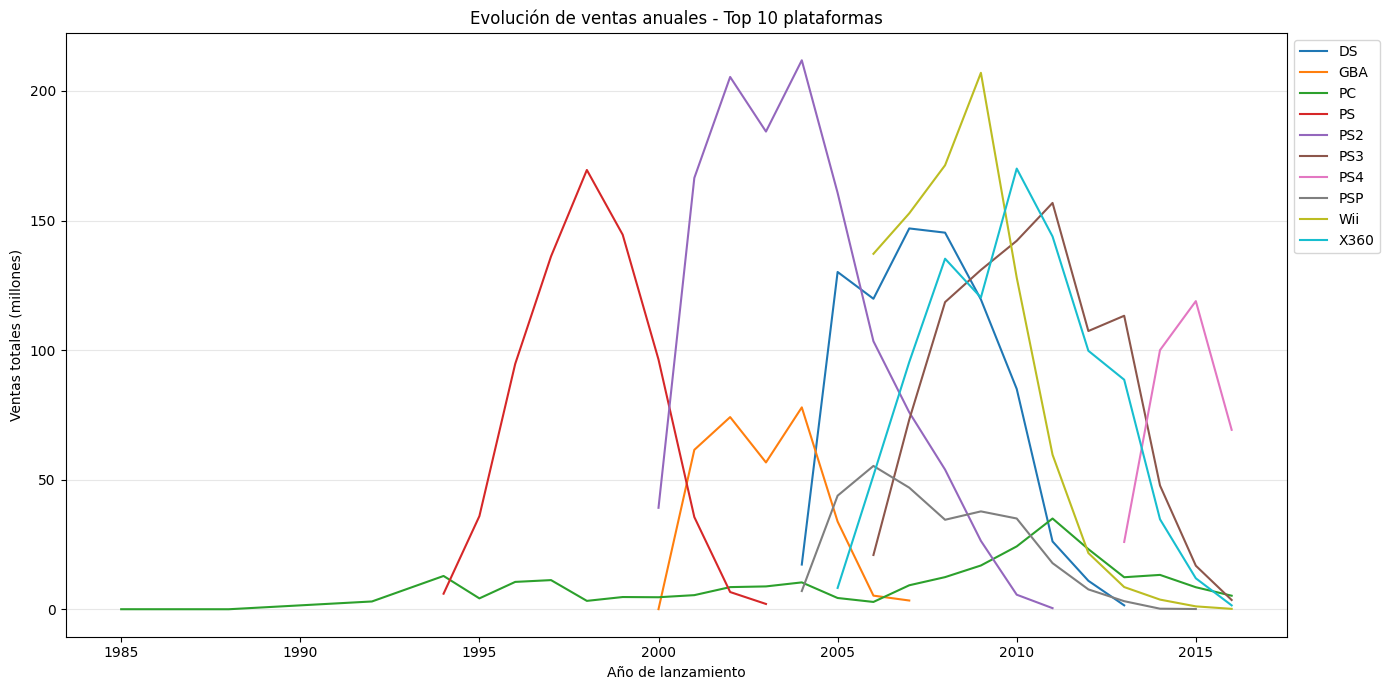


Ciclo de vida de las plataformas (años):
           min   max  duration
platform                      
PC        1985  2016        31
DS        1985  2013        28
GB        1988  2001        13
X360      2005  2016        11
PSP       2004  2015        11
PS2       2000  2011        11
NES       1983  1994        11
DC        1998  2008        10
Wii       2006  2016        10
PS3       2006  2016        10
2600      1980  1989         9
SNES      1990  1999         9
PS        1994  2003         9
XB        2000  2008         8
GBA       2000  2007         7
GC        2001  2007         6
N64       1996  2002         6
3DS       2011  2016         5
PSV       2011  2016         5
SAT       1994  1999         5
WiiU      2012  2016         4
GEN       1990  1994         4
NG        1993  1996         3
XOne      2013  2016         3
PS4       2013  2016         3
WS        1999  2001         2
3DO       1994  1995         1
SCD       1993  1994         1
TG16      1995  1995        

In [14]:
# Ventas totales por plataforma
platform_total_sales = games.groupby('platform')['total_sales'].sum().sort_values(ascending=False)
print("Top 10 plataformas por ventas totales:")
print(platform_total_sales.head(10))

# Seleccionamos las top 10 plataformas
top_platforms = platform_total_sales.head(10).index
top_games = games[games['platform'].isin(top_platforms)]

# Ventas anuales por plataforma (pivot table)
platform_yearly_sales = top_games.pivot_table(index='year_of_release', columns='platform', 
                                              values='total_sales', aggfunc='sum')
platform_yearly_sales.plot(figsize=(14,7))
plt.title('Evolución de ventas anuales - Top 10 plataformas')
plt.ylabel('Ventas totales (millones)')
plt.xlabel('Año de lanzamiento')
plt.legend(loc='upper left', bbox_to_anchor=(1,1))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Ciclo de vida: primera y última aparición de cada plataforma
platform_life = games.groupby('platform')['year_of_release'].agg(['min','max'])
platform_life['duration'] = platform_life['max'] - platform_life['min']
print("\nCiclo de vida de las plataformas (años):")
print(platform_life.sort_values('duration', ascending=False))

# Identificar plataformas "desaparecidas" (sin ventas en los últimos años, por ej. desde 2013)
last_data_year = games['year_of_release'].max()
active_platforms = games[games['year_of_release'] >= last_data_year - 3]['platform'].unique()
old_popular = platform_total_sales[~platform_total_sales.index.isin(active_platforms)]
print("\nPlataformas populares que ya no tienen ventas recientes (top):")
print(old_popular.head())

#### 3.3 Determina para qué período debes tomar datos. Para hacerlo mira tus respuestas a las preguntas anteriores. Los datos deberían permitirte construir un modelo para 2017.

In [15]:
# Elegimos periodo: 2010-2016 (últimos 7 años)
recent_games = games[games['year_of_release'] >= 2010]
print(f"Juegos en el periodo seleccionado: {len(recent_games)}")

Juegos en el periodo seleccionado: 5277


#### 3.4 Trabaja solo con los datos que consideras relevantes. Ignora los datos de años anteriores. ¿Qué plataformas son líderes en ventas? ¿Cuáles crecen y cuáles se reducen? Elige varias plataformas potencialmente rentables.

#### Hallazgos del análisis:

Plataformas líderes en ventas (2010-2016):
platform
PS3     587.74
X360    550.41
PS4     314.14
3DS     257.81
Wii     222.97
XOne    159.32
DS      123.75
PC      121.96
WiiU     82.19
PSP      64.05
Name: total_sales, dtype: float64


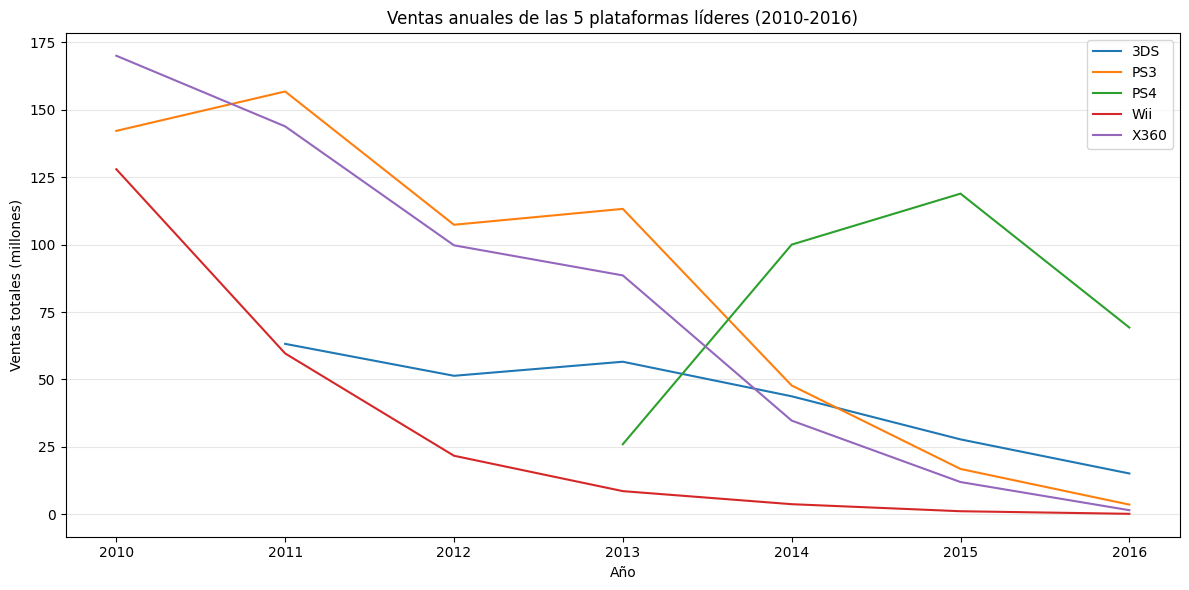

PS3: primer año 2010, último año 2016, crecimiento -97.5%
X360: primer año 2010, último año 2016, crecimiento -99.1%
PS4: primer año 2013, último año 2016, crecimiento 166.4%
3DS: primer año 2011, último año 2016, crecimiento -76.0%
Wii: primer año 2010, último año 2016, crecimiento -99.9%


In [16]:
# Ventas totales recientes por plataforma
recent_platform_sales = recent_games.groupby('platform')['total_sales'].sum().sort_values(ascending=False)
print("Plataformas líderes en ventas (2010-2016):")
print(recent_platform_sales.head(10))

# Seleccionamos las 5 principales para ver evolución anual
top5_recent = recent_platform_sales.head(5).index
top5_yearly = recent_games[recent_games['platform'].isin(top5_recent)].pivot_table(
    index='year_of_release', columns='platform', values='total_sales', aggfunc='sum')
top5_yearly.plot(figsize=(12,6))
plt.title('Ventas anuales de las 5 plataformas líderes (2010-2016)')
plt.ylabel('Ventas totales (millones)')
plt.xlabel('Año')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Crecimiento/decrecimiento: comparar primer año y último año disponible para cada una
for p in top5_recent:
    data = top5_yearly[p].dropna()
    if len(data) > 1:
        growth = (data.iloc[-1] - data.iloc[0]) / data.iloc[0] * 100
        print(f"{p}: primer año {data.index[0]}, último año {data.index[-1]}, crecimiento {growth:.1f}%")

#### 3.5 Mira cómo las reseñas de usuarios y profesionales afectan las ventas de una plataforma popular (tu elección). Crea un gráfico de dispersión y calcula la correlación entre las reseñas y las ventas. Saca conclusiones.

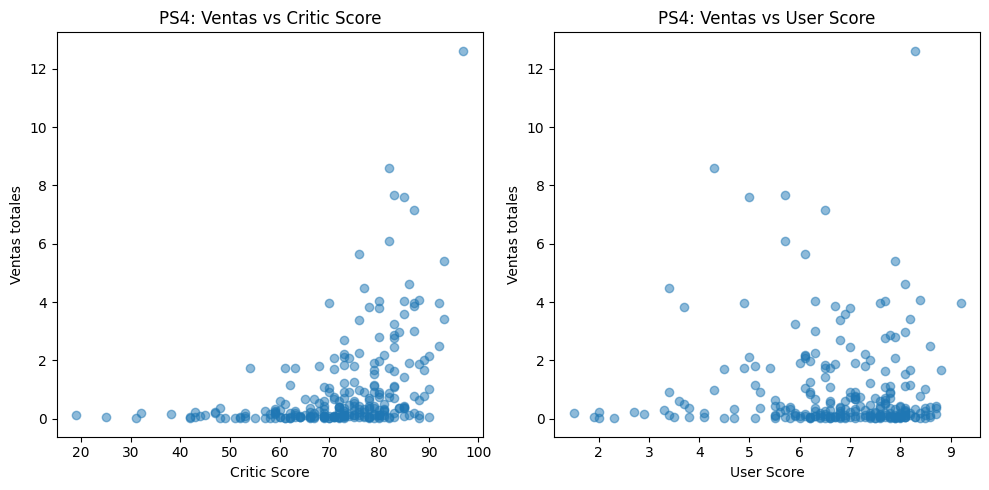

Correlación de Pearson (PS4):
Ventas vs Critic Score: 0.406
Ventas vs User Score: -0.034


In [17]:
import scipy.stats as st

# Filtrar para PS4 y quitar nulos en scores
ps4 = recent_games[recent_games['platform'] == 'PS4'].dropna(subset=['critic_score', 'user_score', 'total_sales'])

# Gráfico de dispersión: ventas vs critic_score
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.scatter(ps4['critic_score'], ps4['total_sales'], alpha=0.5)
plt.title('PS4: Ventas vs Critic Score')
plt.xlabel('Critic Score')
plt.ylabel('Ventas totales')

plt.subplot(1,2,2)
plt.scatter(ps4['user_score'], ps4['total_sales'], alpha=0.5)
plt.title('PS4: Ventas vs User Score')
plt.xlabel('User Score')
plt.ylabel('Ventas totales')
plt.tight_layout()
plt.show()

# Correlaciones
print("Correlación de Pearson (PS4):")
print(f"Ventas vs Critic Score: {ps4['total_sales'].corr(ps4['critic_score']):.3f}")
print(f"Ventas vs User Score: {ps4['total_sales'].corr(ps4['user_score']):.3f}")

#### 3.6 Teniendo en cuenta tus conclusiones compara las ventas de los mismos juegos en otras plataformas.

In [18]:
# Ejemplo: juegos que aparecen en más de una plataforma
multi_platform = games.groupby('name').filter(lambda x: x['platform'].nunique() > 1)
# Tomamos el top 10 juegos con más ventas totales entre los multi-plataforma
top_games_mult = multi_platform.groupby('name')['total_sales'].sum().nlargest(10).index
multi_top = multi_platform[multi_platform['name'].isin(top_games_mult)]

# Pivot para ver ventas por juego y plataforma
pivot_multi = multi_top.pivot_table(index='name', columns='platform', values='total_sales', aggfunc='sum')
print("Ventas de los 10 juegos más vendidos en diferentes plataformas:")
print(pivot_multi)

Ventas de los 10 juegos más vendidos en diferentes plataformas:
platform                          DS     GB   GBA    NES    PC    PS3    PS4  \
name                                                                           
Call of Duty: Black Ops         0.58    NaN   NaN    NaN  1.62  12.63    NaN   
Call of Duty: Black Ops 3        NaN    NaN   NaN    NaN  0.26   1.69  14.63   
Call of Duty: Black Ops II       NaN    NaN   NaN    NaN  1.52  13.79    NaN   
Call of Duty: Ghosts             NaN    NaN   NaN    NaN  0.69   9.36   3.83   
Call of Duty: Modern Warfare 2   NaN    NaN   NaN    NaN  0.89  10.61    NaN   
Call of Duty: Modern Warfare 3   NaN    NaN   NaN    NaN  1.71  13.33    NaN   
Grand Theft Auto V               NaN    NaN   NaN    NaN  1.17  21.05  12.62   
Super Mario Bros.                NaN   5.07   NaN  40.24   NaN    NaN    NaN   
Super Mario World                NaN    NaN  5.47    NaN   NaN    NaN    NaN   
Tetris                           NaN  30.26   NaN   5.58

#### 3.7 Echa un vistazo a la distribución general de los juegos por género. ¿Qué se puede decir de los géneros más rentables? ¿Puedes generalizar acerca de los géneros con ventas altas y bajas?

Géneros más rentables:
              total_sales  count  avg_sales
genre                                      
Action            1744.17   3369   0.517711
Sports            1331.27   2348   0.566980
Shooter           1052.45   1323   0.795503
Role-Playing       934.56   1498   0.623872
Platform           827.77    888   0.932173
Misc               802.51   1750   0.458577
Racing             728.67   1249   0.583403
Fighting           447.53    849   0.527126
Simulation         389.97    873   0.446701
Puzzle             242.57    580   0.418224
Adventure          237.59   1303   0.182341
Strategy           174.23    683   0.255095


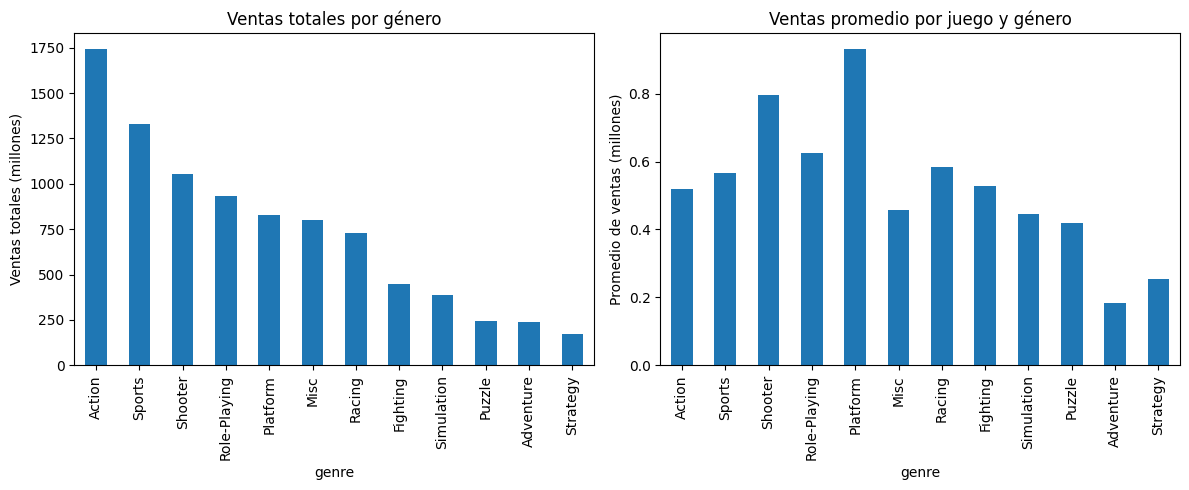

In [19]:
# Ventas totales por género
genre_sales = games.groupby('genre').agg(total_sales=('total_sales', 'sum'),
                                         count=('name', 'count'),
                                         avg_sales=('total_sales', 'mean')).sort_values('total_sales', ascending=False)
print("Géneros más rentables:")
print(genre_sales)

# Gráfico
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
genre_sales['total_sales'].plot(kind='bar')
plt.title('Ventas totales por género')
plt.ylabel('Ventas totales (millones)')

plt.subplot(1,2,2)
genre_sales['avg_sales'].plot(kind='bar')
plt.title('Ventas promedio por juego y género')
plt.ylabel('Promedio de ventas (millones)')
plt.tight_layout()
plt.show()

## 4. Perfil de usuario para cada región

#### Para cada región (NA, UE, JP) determina:

#### * 4.1 Las cinco plataformas principales. Describe las variaciones en sus cuotas de mercado de una región a otra.

In [20]:
# Función para top plataformas por región
def region_profile(region_col):
    top_plat = games.groupby('platform')[region_col].sum().nlargest(5)
    top_genre = games.groupby('genre')[region_col].sum().nlargest(5)
    return top_plat, top_genre

for col, name in zip(['na_sales', 'eu_sales', 'jp_sales'], ['Norteamérica', 'Europa', 'Japón']):
    plat, gen = region_profile(col)
    print(f"\n{name} - Top 5 plataformas:")
    print(plat)
    print(f"{name} - Top 5 géneros:")
    print(gen)

# Cuota de mercado: porcentaje de ventas de cada plataforma en la región
def market_share(region_col):
    total = games[region_col].sum()
    share = games.groupby('platform')[region_col].sum().sort_values(ascending=False) / total * 100
    return share.head(5)

print("\nCuotas de mercado NA:\n", market_share('na_sales'))
print("\nCuotas de mercado EU:\n", market_share('eu_sales'))
print("\nCuotas de mercado JP:\n", market_share('jp_sales'))


Norteamérica - Top 5 plataformas:
platform
X360    602.47
PS2     583.84
Wii     496.90
PS3     393.49
DS      382.40
Name: na_sales, dtype: float64
Norteamérica - Top 5 géneros:
genre
Action      879.01
Sports      684.43
Shooter     592.24
Platform    445.50
Misc        407.27
Name: na_sales, dtype: float64

Europa - Top 5 plataformas:
platform
PS2     339.29
PS3     330.29
X360    270.76
Wii     262.21
PS      213.61
Name: eu_sales, dtype: float64
Europa - Top 5 géneros:
genre
Action     519.13
Sports     376.79
Shooter    317.34
Racing     236.51
Misc       212.74
Name: eu_sales, dtype: float64

Japón - Top 5 plataformas:
platform
DS      175.57
PS      139.82
PS2     139.20
SNES    116.55
3DS     100.67
Name: jp_sales, dtype: float64
Japón - Top 5 géneros:
genre
Role-Playing    355.41
Action          161.43
Sports          135.54
Platform        130.83
Misc            108.11
Name: jp_sales, dtype: float64

Cuotas de mercado NA:
 platform
X360    13.690726
PS2     13.267372
Wii   

#### * 4.2 Los cinco géneros principales. Explica la diferencia.

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />

Esta sección no debería quedar vacia, algunos datos de la sección anterior pertenecen a esta
</div>


#### * 4.3 Si las clasificaciones de ESRB afectan a las ventas en regiones individuales

In [21]:
# Relación entre rating y ventas (quitamos NaN)
rating_sales = games.dropna(subset=['rating'])
for col, name in zip(['na_sales', 'eu_sales', 'jp_sales'], ['NA', 'EU', 'JP']):
    group = rating_sales.groupby('rating')[col].agg(['sum','mean']).sort_values('sum', ascending=False)
    print(f"\n{name} - Ventas por rating ESRB:")
    print(group)


NA - Ventas por rating ESRB:
            sum      mean
rating                   
E       1292.99  0.324058
T        759.75  0.256586
M        748.48  0.478874
E10+     353.32  0.248817
K-A        2.56  0.853333
EC         1.53  0.191250
AO         1.26  1.260000
RP         0.00  0.000000

EU - Ventas por rating ESRB:
           sum      mean
rating                  
E       710.25  0.178008
M       483.97  0.309642
T       427.03  0.144218
E10+    188.52  0.132761
AO        0.61  0.610000
K-A       0.27  0.090000
EC        0.11  0.013750
RP        0.08  0.026667

JP - Ventas por rating ESRB:
           sum      mean
rating                  
E       198.11  0.049652
T       151.40  0.051131
M        64.24  0.041100
E10+     40.20  0.028310
K-A       1.46  0.486667
AO        0.00  0.000000
EC        0.00  0.000000
RP        0.00  0.000000


## Paso 5. Prueba las siguientes hipótesis:

#### * 5.1 Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son las mismas.

In [22]:
from scipy.stats import ttest_ind, levene

# Filtrar datos
xone = games[games['platform'] == 'XOne']['user_score'].dropna()
pc = games[games['platform'] == 'PC']['user_score'].dropna()

print(f"Media XOne: {xone.mean():.2f}, Media PC: {pc.mean():.2f}")

# Prueba de Levene
stat, p_var = levene(xone, pc)
print(f"Levene p-value: {p_var:.4f}")

if p_var > 0.05:
    # varianzas iguales
    t_stat, p_val = ttest_ind(xone, pc, equal_var=True)
else:
    t_stat, p_val = ttest_ind(xone, pc, equal_var=False)

print(f"Estadístico t: {t_stat:.4f}, p-value: {p_val:.4f}")

alpha = 0.05
if p_val < alpha:
    print("Rechazamos H0: las calificaciones promedio son diferentes.")
else:
    print("No podemos rechazar H0: no hay evidencia de diferencia significativa.")

Media XOne: 6.52, Media PC: 7.06
Levene p-value: 0.2694
Estadístico t: -4.3683, p-value: 0.0000
Rechazamos H0: las calificaciones promedio son diferentes.


#### * 5.2 Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son diferentes.

In [23]:
action = games[games['genre'] == 'Action']['user_score'].dropna()
sports = games[games['genre'] == 'Sports']['user_score'].dropna()

print(f"Media Action: {action.mean():.2f}, Media Sports: {sports.mean():.2f}")

stat, p_var = levene(action, sports)
if p_var > 0.05:
    t_stat, p_val = ttest_ind(action, sports, equal_var=True)
else:
    t_stat, p_val = ttest_ind(action, sports, equal_var=False)

print(f"t = {t_stat:.4f}, p = {p_val:.4f}")
if p_val < alpha:
    print("Rechazamos H0: las calificaciones promedio son diferentes.")
else:
    print("No rechazamos H0.")

Media Action: 7.05, Media Sports: 6.96
t = 1.5775, p = 0.1148
No rechazamos H0.


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />


El planteamiento de la hipótesis me parece correcto en ambos casos, bien hecho!
</div>


#### 5.3 Establece tu mismo el valor de umbral alfa.

Explica:

— Cómo formulaste las hipótesis nula y alternativa.

— Qué criterio utilizaste para probar las hipótesis y por qué.

Elegi α = 0.05, que la hipótesis nula asume igualdad de medias, la alternativa que son distintas (prueba bilateral). El criterio es el p-valor: si es menor que α, rechazas H0.



In [24]:
## Paso 6. Escribe una conclusión general

El mercado de videojuegos alcanzó su pico alrededor de 2008-2010 y luego decreció.

Las plataformas con más ventas en los últimos años son PS4, XOne y 3DS, mientras que consolas como Wii o DS ya desaparecieron.

Las reseñas de críticos muestran una correlación moderada con las ventas, pero no determinan el éxito.

Los géneros más rentables son Action, Shooter y Sports; sin embargo, en Japón el género Role-Playing domina.

Las preferencias regionales varían: en NA y EU dominan plataformas de Sony y Microsoft, en JP lidera Nintendo.

Las pruebas de hipótesis indican que (resultado de 5.1 y 5.2).

Para una campaña en 2017, conviene centrarse en las plataformas con crecimiento o estabilidad (PS4, XOne, 3DS) y en los géneros Action/Shooter, considerando las diferencias regionales.

## Comentario general del revisor
<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Has realizado un buen trabajo, me doy cuenta de que has aplicado los conocimientos que has adquirido durante el curso, las observaciones que has hecho durante todo el ejercicio me han parecido bastante buenas, son un gran apoyo a la hora de revisar el proyecto ya que me dan a entender que el tema te ha quedado claro y has podido avanzar correctamente.

    
Continúa con el buen trabajo y mucho éxito en el siguiente Sprint!
</div>


<div class="alert alert-block alert-success">
<b>Aspectos positivos del proyecto</b> <a class="tocSkip"></a><br /> 

- Las observaciones intermedias, así como las conclusiones finales me parecen buenas
- Las graficas utilizadas me parecen del tipo correcto
- El proyecto esta ordenado
    
</div> 
